Problem 1: ConvNets Transfer Learning (5 points)

Goal: Build convolutional neural networks (ConvNets) based on ResNet101, InceptionV3, and EfficientNetB1, using transfer learning to classify images of fruits and vegetables into their respective classes. Analyze the performance of the constructed ConvNets of varying sizes in terms of classification accuracy as well as computational efforts required for inference.

Data: The Fruits-360 dataset contains 100×100 images for 251 different varieties of fruits and vegetables. Processing the images should be consistent with settings described in Homework 2.

In [1]:
from google.colab import userdata

## IMPORT API KEY - UNCOMMENT APPLICABLE LINES WHEN RUNNING DIFFERENT KERNELS
# Import KAGGLE_API_KEY from .env
# KAGGLE_API_TOKEN = os.getenv("KAGGLE_API_KEY")
# Define directly - delete key before uploading to GitHub
# KAGGLE_API_TOKEN =
# When running in Colab - define in web using Colab Secrets
KAGGLE_API_TOKEN = userdata.get("KAGGLE_API_KEY")

# update any packages in Colab server
# %pip install --upgrade numpy pandas kagglehub torch torchvision IPython

In [2]:
# Import necessary libraries
from pathlib import Path
from dotenv import load_dotenv
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
import torchvision
import torchvision.transforms as transforms
from IPython.display import display, Image
import time
import copy

In [3]:
# Import and Process Fruits-360 Dataset, same as HW2

# Import dataset from Kaggle
# Kagglehub reads KAGGLE_API_TOKEN from environment (set in cell above)
os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN
# Running locally:
# path = kagglehub.dataset_download("moltean/fruits", output_dir="/content/fruits-360")
# On Colab: use /content to avoid cache disk limits; locally omit output_dir to use cache
path = kagglehub.dataset_download("moltean/fruits")

# Locate Training and Test subfolders (Fruits-360 dataset structure)
path = Path(path)
# Kaggle zip may nest Training/Test inside a subfolder (e.g. fruits-360/Training)
# Search recursively for Training directory
train_path = None
for p in path.rglob("Training"):
    if p.is_dir() and (p.parent / "Test").exists():
        train_path = p
        break
if train_path is not None:
    test_path = train_path.parent / "Test"
else:
    # Fallback: check direct children
    if (path / "Training").exists():
        train_path, test_path = path / "Training", path / "Test"
    else:
        raise FileNotFoundError(
            f"Could not find Training/Test folders. Dataset root: {path}\n"
            f"Contents: {[d.name for d in path.iterdir()] if path.exists() else 'path does not exist'}"
        )

# Load image datasets with placeholder transform (will add scaling/normalization in next steps)
print("Loading datasets")
train_dataset = torchvision.datasets.ImageFolder(str(train_path), transform=transforms.ToTensor())
test_dataset = torchvision.datasets.ImageFolder(str(test_path), transform=transforms.ToTensor())

print(f"Dataset downloaded to: {path}")
print(f"Training samples: {len(train_dataset)} | Classes: {len(train_dataset.classes)}")
print(f"Test samples: {len(test_dataset)}")

## Image Preprocessing

# 1. Image scaling (100x100 -> 299x299):
# Larger size for Inception
image_size = 299

# 2. Image normalization values for RGB to [-1, 1]
normalize_means = [0.5, 0.5, 0.5]
normalize_stds = [0.5, 0.5, 0.5]

# 3. Data augmentation and normalization for training; only normalization for validation/test
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_means, std=normalize_stds)
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_means, std=normalize_stds)
])

# Replace raw datasets with transformed datasets
train_dataset = torchvision.datasets.ImageFolder(str(train_path), transform=train_transform)
test_dataset = torchvision.datasets.ImageFolder(str(test_path), transform=test_transform)

# 4. Define training and validation split (85%/15% from train_dataset)
total_train = len(train_dataset)
val_size = int(0.15 * total_train)
train_size = total_train - val_size

SHUFFLE_SEED = 42
torch.manual_seed(SHUFFLE_SEED)  # set random seed for reproducibility
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SHUFFLE_SEED))

# 5. Define dataloaders with batch size 64 and consistent shuffle with seed
# Smaller batch size due to larger image size
batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, worker_init_fn=lambda worker_id: np.random.seed(SHUFFLE_SEED))
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("Loading success")

Using Colab cache for faster access to the 'fruits' dataset.
Loading datasets
Dataset downloaded to: /kaggle/input/fruits
Training samples: 132448 | Classes: 253
Test samples: 44138
Loading success


In [4]:
## GENERAL HELPER FUNCTIONS

# BASIC TRAIN
def train(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.

    Parameters:
        model (nn.Module): The neural network model.
        loader (DataLoader): DataLoader for training data.
        criterion: Loss function.
        optimizer: Optimization algorithm.
        device: Device to run the training on.

    Returns:
        epoch_loss (float): Average loss for the epoch.
        epoch_acc (float): Accuracy for the epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients

        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Optimize

        running_loss += loss.item() * inputs.size(0)  # Accumulate loss

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# BASIC EVAL
def evaluate(model, loader, criterion, device):
    # Compute 3 accuracy percentages
    """
    Evaluate the model on validation or test data.

    Parameters:
        model (nn.Module): The neural network model.
        loader (DataLoader): DataLoader for validation/test data.
        criterion: Loss function.
        device: Device to run the evaluation on.

    Returns:
        epoch_loss (float): Average loss for the epoch.
        epoch_acc (float): Accuracy for the epoch.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss

            running_loss += loss.item() * inputs.size(0)  # Accumulate loss

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# PLOT LOSS CURVES
def plot_loss(curve, dataset, model_name, output_dir="Plot JPGs"):
    # Plot and save loss curve
    # dataset = [Training, Validation]
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    plt.figure()
    plt.plot(curve)
    plt.xlabel("Epoch")
    if dataset == 'Training':
        plt.ylabel("Training Loss")
    elif dataset == 'Validation':
        plt.ylabel("Validation Loss")

    plt.title(f"Categorical Cross Entropy Loss Curve for {dataset} Dataset, Model: {model_name}")
    filename = f"{output_dir}/LossCurve_{dataset}_Dataset_Model_{model_name}.jpg"

    plt.savefig(filename)
    plt.close()

# MODEL TRAIN
def train_model(model, train_loader, test_loader, criterion, optimizer, device, num_epochs=50):
    """
    Train the model and evaluate on test data after each epoch.

    Parameters:
        model (nn.Module): The neural network model.
        train_loader (DataLoader): DataLoader for training data.
        test_loader (DataLoader): DataLoader for test data.
        criterion: Loss function.
        optimizer: Optimization algorithm.
        device: Device to run the training on.
        num_epochs (int): Number of training epochs.

    Returns:
        Training and validation loss and accuracy.
    """
    training_loss_curve = []
    validation_loss_curve = []
    training_accuracy = []
    validation_accuracy = []

    for epoch in range(num_epochs):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)

        training_loss_curve.append(train_loss)
        training_accuracy.append(train_acc)
        validation_loss_curve.append(val_loss)
        validation_accuracy.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    return training_loss_curve, validation_loss_curve, training_accuracy, validation_accuracy


Model Architecture

Background: The learned features in pre-trained models can be repurposed or transferred to another ConvNet designed for a specific task. Several complex pre-trained ConvNet models are made available by popular deep learning libraries. The pre-trained neural networks of varying sizes, Efficient Net B1, Inception V3, and ResNet 101 neural networks, could be used to classify images of fruits and vegetables. Weights corresponding to pre-training on ImageNet should be used as the initial weights for your pre-trained models.

Architecture: Because the above-mentioned ConvNets were previously trained to classify different numbers of image classes, the constructed models need to be customized such that they can classify 251 classes of fruits and vegetables. To achieve this, an additional Dense layer with 251 units and Softmax activation function can be added at the end of the pre-trained models. As the pre-trained ConvNets have sophisticated architectures and consist of several cyclic networks, sequential style modeling cannot be used here. Instead, the modified ConvNets for classifying fruits/vegetables can be built following an alternate modeling scheme termed as the functional model. In this assignment, you will need to:

1. Implement ResNet101, InceptionV3, and EfficientNetB1 models with a custom fully-connected layer (number_of_classes=251).
2. Incorporate pre-trained weights obtained from ImageNet for all three ConvNets. Proceed to train the constructed models while freezing the original weights of the convolutional blocks.
3. Freeze the weights of the original layers within the pre-trained models, and subsequently fine-tune the remaining layers. After retraining the modified models, elaborate on the roles that transfer learning and frozen layers play within transfer learning tasks.
4. Measure the computational time required for the prediction step over the testing dataset performed with all three trained ConvNets.

Training: All models should be trained with the ADAM optimizer to minimize the categorical cross-entropy. The new ConvNet models should be trained for 50 epochs (or 20ish if training is compute-intensive) using the data generators created for the fruits-360 dataset. Please note that some pre-trained models are large and might consume large computational resources for each step. It is recommended that the training process is performed on Google Colab / Google Cloud using a GPU or a TPU.

In [5]:
## 1. Set up ResNet101, InceptionV3, and EfficientNetB1 models with a custom fully-connected layer

NUM_CLASSES = 253

# ResNet101
ResNet101 = torchvision.models.resnet101(pretrained=True)
# Replace the final fully-connected layer to match number of classes
in_features_resnet = ResNet101.fc.in_features
ResNet101.fc = nn.Linear(in_features_resnet, NUM_CLASSES)

# InceptionV3
# Use pretrained weights; disable auxiliary logits for simplicity during training
InceptionV3 = torchvision.models.inception_v3(pretrained=True)
InceptionV3.aux_logits = False
in_features_inception = InceptionV3.fc.in_features
InceptionV3.fc = nn.Linear(in_features_inception, NUM_CLASSES)

# EfficientNetB1
EfficientNetB1 = torchvision.models.efficientnet_b1(pretrained=True)
# EfficientNetB1's classifier is a Sequential; replace the final Linear layer
in_features_effnet = EfficientNetB1.classifier[-1].in_features
EfficientNetB1.classifier[-1] = nn.Linear(in_features_effnet, NUM_CLASSES)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 217MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 207MB/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 147MB/s]


In [6]:
# First Experiment HELPER
def run_first_experiment(model, model_name, train_loader, val_loader, test_loader, max_epochs=50):
    # Run full experiment: instantiate model, train, evaluate accuracies, plot, return results to dataframe
    # Train constructed models with pre-trained ImageNet weights and custom FC layer

    # Detect Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Freeze all original layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze only the non-original layers (new classifier head)
    # ResNet / Inception use `.fc`, EfficientNet uses `.classifier`.
    if hasattr(model, "fc") and isinstance(model.fc, nn.Module):
        for param in model.fc.parameters():
            param.requires_grad = True
    if hasattr(model, "classifier") and isinstance(model.classifier, nn.Module):
        for param in model.classifier.parameters():
            param.requires_grad = True

    # Move model to device
    model.to(device)

    # Define Optimizer
    # Adam, Categorical Cross Entropy
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()))

    # Train
    training_loss_curve, validation_loss_curve, training_accuracy, validation_accuracy = train_model(
        model, train_loader, val_loader, criterion, optimizer, device, max_epochs
    )
    print("Training complete")
    # Evaluate final test
    final_test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print("Evaluation complete")
    # Save plots
    plot_loss(training_loss_curve, "Training", model_name, output_dir="Plot JPGs Ex1")
    plot_loss(validation_loss_curve, "Validation", model_name, output_dir="Plot JPGs Ex1")
    print("Plots created")
    # return results
    row = {
        'Model Name': model_name,
        'Epochs': max_epochs,
        'Training Accuracy (%)': training_accuracy[-1] * 100.0,
        'Validation Accuracy (%)': validation_accuracy[-1] * 100.0,
        'Test Accuracy (%)': test_acc * 100.0,
        'Final Test Loss': final_test_loss
    }
    print("Experiment complete")
    return row


In [7]:

## 2. Train the 3x models with frozen original layers and pre-trained ImageNet weights
# Report: Training accuracy, validation accuracy, training loss, validation loss

MAX_EPOCHS = 5

first_experiment_df = pd.DataFrame(columns=[
    'Model Name', 'Epochs', 'Training Accuracy (%)', 'Validation Accuracy (%)', 'Test Accuracy (%)', 'Final Test Loss'
])

first_experiment_df.loc[len(first_experiment_df)] = run_first_experiment(ResNet101, "ResNet101", train_loader, val_loader, test_loader, max_epochs=MAX_EPOCHS)


Using device: cuda
Epoch 1/5 | Train Loss: 0.4579 | Train Acc: 0.9299 | Val Loss: 0.0474 | Val Acc: 0.9932
Epoch 2/5 | Train Loss: 0.0419 | Train Acc: 0.9925 | Val Loss: 0.0223 | Val Acc: 0.9955
Epoch 3/5 | Train Loss: 0.0254 | Train Acc: 0.9943 | Val Loss: 0.0428 | Val Acc: 0.9886
Epoch 4/5 | Train Loss: 0.0252 | Train Acc: 0.9929 | Val Loss: 0.0122 | Val Acc: 0.9972
Epoch 5/5 | Train Loss: 0.0177 | Train Acc: 0.9949 | Val Loss: 0.0158 | Val Acc: 0.9951


In [8]:
first_experiment_df.loc[len(first_experiment_df)] = run_first_experiment(InceptionV3, "InceptionV3", train_loader, val_loader, test_loader, max_epochs=MAX_EPOCHS)


Using device: cuda
Epoch 1/5 | Train Loss: 0.8064 | Train Acc: 0.8663 | Val Loss: 0.1243 | Val Acc: 0.9794
Epoch 2/5 | Train Loss: 0.1621 | Train Acc: 0.9632 | Val Loss: 0.0558 | Val Acc: 0.9902
Epoch 3/5 | Train Loss: 0.1184 | Train Acc: 0.9687 | Val Loss: 0.0379 | Val Acc: 0.9928
Epoch 4/5 | Train Loss: 0.1005 | Train Acc: 0.9704 | Val Loss: 0.0288 | Val Acc: 0.9930
Epoch 5/5 | Train Loss: 0.0909 | Train Acc: 0.9724 | Val Loss: 0.0276 | Val Acc: 0.9925


In [9]:
first_experiment_df.loc[len(first_experiment_df)] = run_first_experiment(EfficientNetB1, "EfficientNetB1", train_loader, val_loader, test_loader, max_epochs=MAX_EPOCHS)


Using device: cuda
Epoch 1/5 | Train Loss: 0.4341 | Train Acc: 0.9483 | Val Loss: 0.0378 | Val Acc: 0.9973
Epoch 2/5 | Train Loss: 0.0419 | Train Acc: 0.9947 | Val Loss: 0.0174 | Val Acc: 0.9986
Epoch 3/5 | Train Loss: 0.0236 | Train Acc: 0.9963 | Val Loss: 0.0098 | Val Acc: 0.9989
Epoch 4/5 | Train Loss: 0.0159 | Train Acc: 0.9972 | Val Loss: 0.0056 | Val Acc: 0.9993
Epoch 5/5 | Train Loss: 0.0121 | Train Acc: 0.9975 | Val Loss: 0.0042 | Val Acc: 0.9996


In [15]:
# Second Experiment HELPER (fine-tuning non-original layers)
def run_second_experiment(model, model_name, train_loader, val_loader, test_loader, max_epochs=50):
    # Detect Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device} for fine-tuning {model_name}")

    # Freeze all original layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last block of each model + FC layer
    # ResNet101: unfreeze model.layer4
    # InceptionV3: unfreeze model.Mixed_7a, Mixed_7b, Mixed_7c
    # EfficientNetB1: unfreeze last few blocks in model.features[-3:]
    # ResNet / Inception use .fc, EfficientNet uses .classifier

     # --- ResNet101: unfreeze last residual block (layer4) and classifier ---
    if hasattr(model, "layer4") and isinstance(model.layer4, nn.Module):
        for param in model.layer4.parameters():
            param.requires_grad = True
    if hasattr(model, "fc") and isinstance(model.fc, nn.Module):
        for param in model.fc.parameters():
            param.requires_grad = True

    # --- InceptionV3: unfreeze final inception blocks and classifier ---
    for attr in ["Mixed_7a", "Mixed_7b", "Mixed_7c"]:
        if hasattr(model, attr):
            block = getattr(model, attr)
            if isinstance(block, nn.Module):
                for param in block.parameters():
                    param.requires_grad = True
    if hasattr(model, "fc") and isinstance(model.fc, nn.Module):
        for param in model.fc.parameters():
            param.requires_grad = True

    # --- EfficientNetB1: unfreeze last few feature blocks and classifier ---
    if hasattr(model, "features") and isinstance(model.features, nn.Module):
        # Unfreeze parameters belonging to the last 3 feature blocks
        params = list(model.features.parameters())
        for param in params[-3:]:
            param.requires_grad = True
    if hasattr(model, "classifier") and isinstance(model.classifier, nn.Module):
        for param in model.classifier.parameters():
            param.requires_grad = True

    # Move model to device
    model.to(device)

    # Use a smaller learning rate for fine-tuning
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    # Train
    training_loss_curve, validation_loss_curve, training_accuracy, validation_accuracy = train_model(
        model, train_loader, val_loader, criterion, optimizer, device, max_epochs
    )
    print("Training complete")
    # Evaluate final test
    final_test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print("Evaluation complete")
    # Save plots
    plot_loss(training_loss_curve, "Training", model_name, output_dir="Plot JPGs Ex2")
    plot_loss(validation_loss_curve, "Validation", model_name, output_dir="Plot JPGs Ex2")
    print("Plots made")
    # return results
    row = {
        'Model Name': model_name,
        'Epochs': max_epochs,
        'Training Accuracy (%)': training_accuracy[-1] * 100.0,
        'Validation Accuracy (%)': validation_accuracy[-1] * 100.0,
        'Test Accuracy (%)': test_acc * 100.0,
        'Final Test Loss': final_test_loss
    }
    print("Experiment complete")
    return row


In [16]:
## 3. Freeze weights of original layers for fine-tune training the remaining layers
# Include logic to measure inference time in seconds

MAX_EPOCHS = 5

# Create copies of trained models for fine-tuning in Experiment 2
ResNet101_fine = copy.deepcopy(ResNet101)
InceptionV3_fine = copy.deepcopy(InceptionV3)
EfficientNetB1_fine = copy.deepcopy(EfficientNetB1)
# Unfreeze the last layer within the experiment function

second_experiment_df = pd.DataFrame(columns=[
    'Model Name', 'Epochs', 'Training Accuracy (%)', 'Validation Accuracy (%)', 'Test Accuracy (%)', 'Final Test Loss'
])

# Use the fine-tuning copies created after Experiment 1
second_experiment_df.loc[len(second_experiment_df)] = run_second_experiment(ResNet101_fine, "ResNet101_fine", train_loader, val_loader, test_loader, max_epochs=MAX_EPOCHS)


Using device: cuda for fine-tuning ResNet101_fine
Epoch 1/5 | Train Loss: 0.0173 | Train Acc: 0.9957 | Val Loss: 0.0042 | Val Acc: 0.9995
Epoch 2/5 | Train Loss: 0.0072 | Train Acc: 0.9985 | Val Loss: 0.0043 | Val Acc: 0.9993
Epoch 3/5 | Train Loss: 0.0050 | Train Acc: 0.9990 | Val Loss: 0.0028 | Val Acc: 0.9997
Epoch 4/5 | Train Loss: 0.0049 | Train Acc: 0.9991 | Val Loss: 0.0028 | Val Acc: 0.9998
Epoch 5/5 | Train Loss: 0.0054 | Train Acc: 0.9987 | Val Loss: 0.0118 | Val Acc: 0.9976


In [17]:
second_experiment_df.loc[len(second_experiment_df)] = run_second_experiment(InceptionV3_fine, "InceptionV3_fine", train_loader, val_loader, test_loader, max_epochs=MAX_EPOCHS)


Using device: cuda for fine-tuning InceptionV3_fine
Epoch 1/5 | Train Loss: 0.0366 | Train Acc: 0.9887 | Val Loss: 0.0036 | Val Acc: 0.9988
Epoch 2/5 | Train Loss: 0.0130 | Train Acc: 0.9963 | Val Loss: 0.0020 | Val Acc: 0.9997
Epoch 3/5 | Train Loss: 0.0098 | Train Acc: 0.9973 | Val Loss: 0.0022 | Val Acc: 0.9995
Epoch 4/5 | Train Loss: 0.0077 | Train Acc: 0.9977 | Val Loss: 0.0028 | Val Acc: 0.9992
Epoch 5/5 | Train Loss: 0.0068 | Train Acc: 0.9982 | Val Loss: 0.0030 | Val Acc: 0.9994


In [18]:
second_experiment_df.loc[len(second_experiment_df)] = run_second_experiment(EfficientNetB1_fine, "EfficientNetB1_fine", train_loader, val_loader, test_loader, max_epochs=MAX_EPOCHS)


Using device: cuda for fine-tuning EfficientNetB1_fine
Epoch 1/5 | Train Loss: 0.0082 | Train Acc: 0.9983 | Val Loss: 0.0022 | Val Acc: 0.9999
Epoch 2/5 | Train Loss: 0.0056 | Train Acc: 0.9990 | Val Loss: 0.0017 | Val Acc: 0.9999
Epoch 3/5 | Train Loss: 0.0046 | Train Acc: 0.9991 | Val Loss: 0.0013 | Val Acc: 0.9999
Epoch 4/5 | Train Loss: 0.0035 | Train Acc: 0.9994 | Val Loss: 0.0011 | Val Acc: 0.9999
Epoch 5/5 | Train Loss: 0.0030 | Train Acc: 0.9995 | Val Loss: 0.0011 | Val Acc: 0.9999


In [19]:
# Helper function to measure inference time over test dataset

def measure_inference_time(model, test_loader, device):
    model.eval()
    model.to(device)

    correct = 0
    total = 0

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    if device.type == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()
    inference_time = end - start
    test_accuracy = correct / total

    return inference_time, test_accuracy

In [20]:
## 4. Prediction and Measure Computational Time
# Report: Testing accuracy, prediction time, model size

# Models to run
models_to_run = [ResNet101_fine, InceptionV3_fine, EfficientNetB1_fine]

prediction_results_df = pd.DataFrame(columns=[
    'Model', 'Model Size (num. params)', 'Inference Time (sec)', 'Testing Accuracy (%)'
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for model in models_to_run:
    inference_time, test_acc = measure_inference_time(model, test_loader, device)
    model_size = sum(p.numel() for p in model.parameters())

    prediction_results_df.loc[len(prediction_results_df)] = {
    "Model": model.__class__.__name__,
    "Model Size (num. params)": model_size,
    "Inference Time (sec)": inference_time,
    "Testing Accuracy (%)": test_acc * 100.0,
    }


In [ ]:
## DOWNLOAD PLOT FOLDERS TO LOCAL IN CASE OF DISCONNECT

import shutil
from google.colab import files
import os

# Define the names for the downloaded zip files
zip_ex1 = 'Plot_JPGs_Ex1'
zip_ex2 = 'Plot_JPGs_Ex2'

# Check if directories exist on the server and zip them
if os.path.exists("/content/Plot JPGs Ex1"):
    shutil.make_archive(zip_ex1, 'zip', "/content/Plot JPGs Ex1")
    print(f"Created {zip_ex1}.zip")
    files.download(f"{zip_ex1}.zip")
else:
    print("Folder '/content/Plot JPGs Ex1' not found. Make sure the first experiment has run.")

if os.path.exists("/content/Plot JPGs Ex2"):
    shutil.make_archive(zip_ex2, 'zip', "/content/Plot JPGs Ex2")
    print(f"Created {zip_ex2}.zip")
    files.download(f"{zip_ex2}.zip")
else:
    print("Folder '/content/Plot JPGs Ex2' not found. Make sure the second experiment has run.")

Deliverables:

1. Please report the accuracy for both the training and testing datasets obtained after training the modified ConvNets. Also, plot the loss curves for both training and validation datasets. Discuss the roles that transfer learning and frozen layers play within transfer learning tasks.
2. Report the computational time required to predict classification accuracy over the testing dataset with the trained ConvNet models along with their model sizes. Please make sure to measure ONLY the times required for the prediction step; you may use Python’s inbuilt time functions for the same. Discuss the trade-offs between computational resource utilization with the accuracy levels and model sizes for the classification task.
![alt text](<Q1 Reporting Table.png>)
3. Please make sure to submit your working code files along with the final results and the plots.


Model Name,Epochs,Training Accuracy (%),Validation Accuracy (%),Test Accuracy (%),Final Test Loss
ResNet101,5,99.491033,99.511753,97.387738,0.268565
InceptionV3,5,97.241986,99.250013,96.393131,0.296943
EfficientNetB1,5,99.747737,99.964766,98.459377,0.223698


Files in /content/Plot JPGs: ['LossCurve_Training_Dataset_Model_Inception3.jpg', 'LossCurve_Validation_Dataset_Model_Inception3.jpg', 'LossCurve_Training_Dataset_Model_EfficientNet.jpg', 'LossCurve_Validation_Dataset_Model_ResNet.jpg', 'LossCurve_Training_Dataset_Model_ResNet.jpg', 'LossCurve_Validation_Dataset_Model_EfficientNet.jpg']


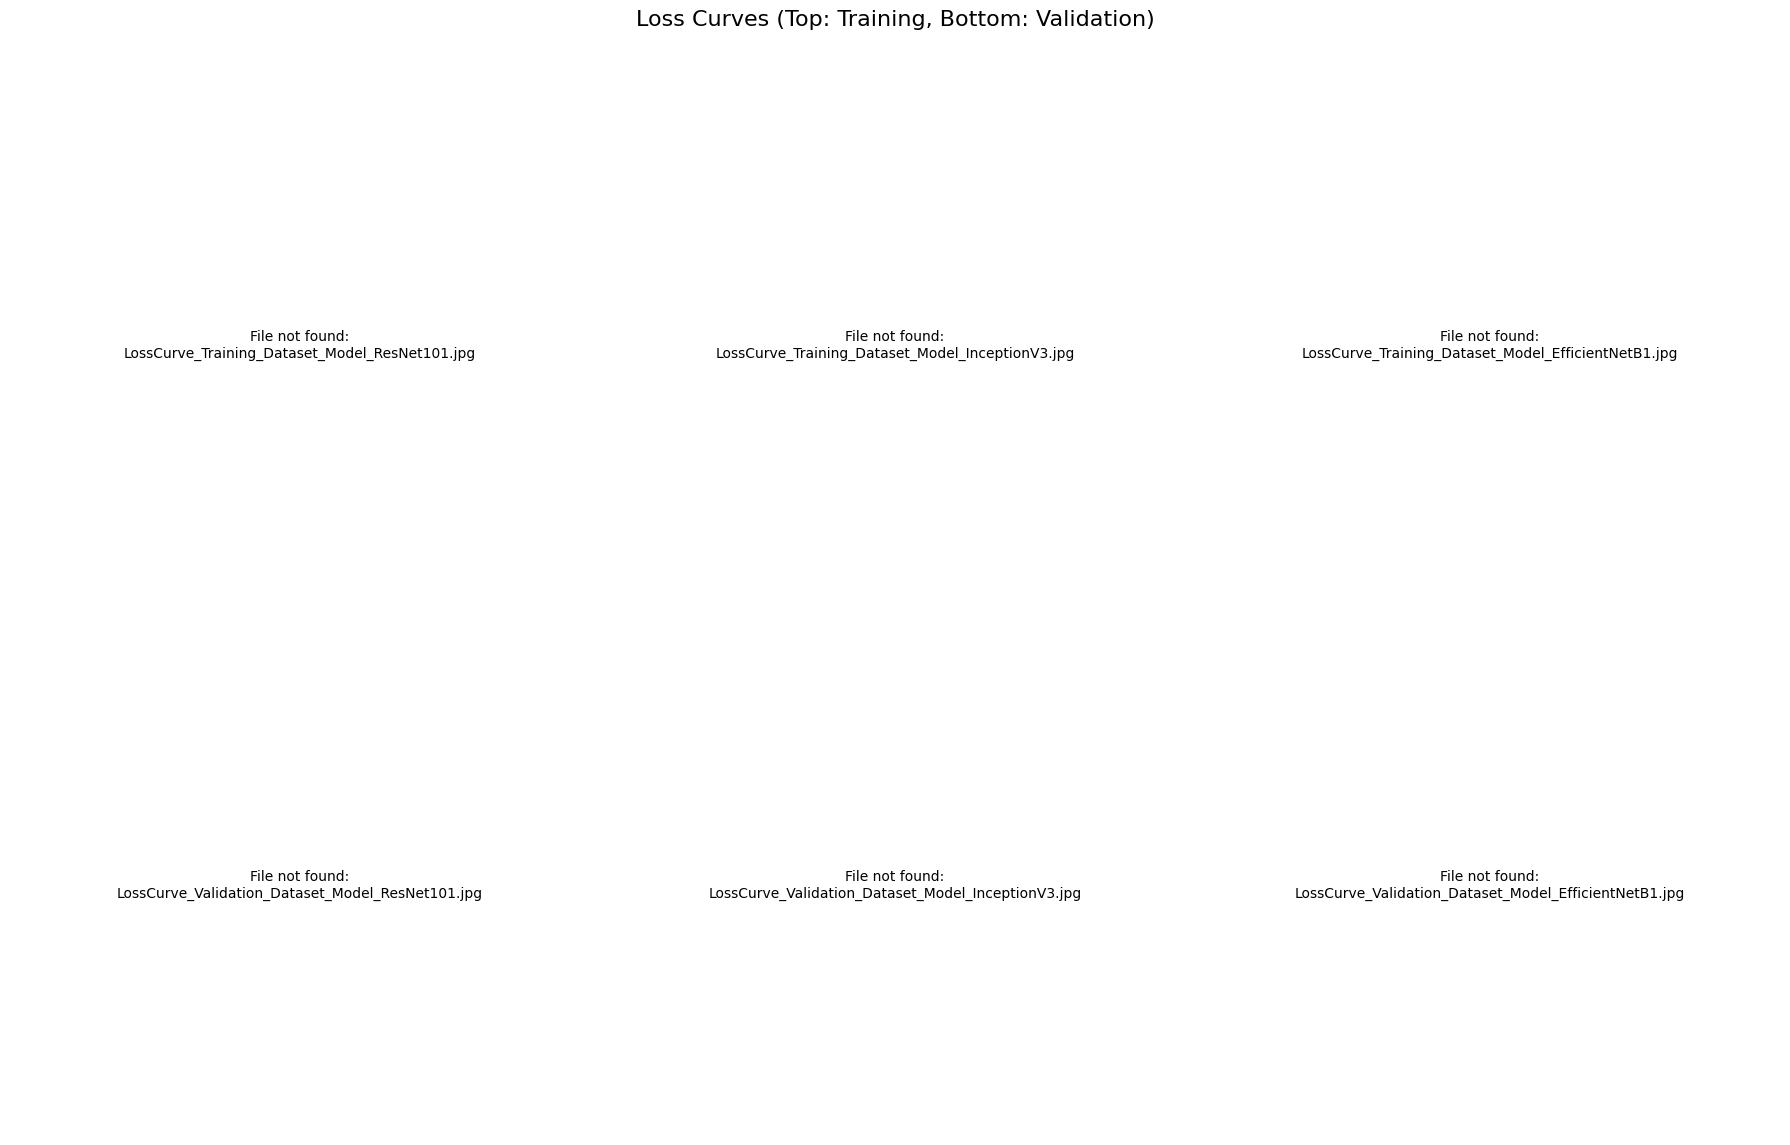

In [21]:
# Deliverable 1: Models with ImageNet weights and custom FC layer
# Dataframe: first_experiment_df

# Report accuracies
# Display as a clean HTML table (use display() in Jupyter instead of print())
try:
    display(first_experiment_df.style.hide(axis=0).set_properties(
        **{'text-align': 'center', 'border': '1px solid #ddd'}
    ).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}]))
except NameError as e:
    print(f"Error: {e}. Run the model training cells first.")

# Print loss curves
# Display in grid 3x2

# Define subfolder and filenames
# If local:
# plot_folder = "HW_03_Transfer/plots"
# If running in Colab online:
plot_folder = "/content/Plot JPGs Ex1"

# Debug: List files to ensure we have the right names
if os.path.exists(plot_folder):
    print(f"Files in {plot_folder}: {os.listdir(plot_folder)}")
else:
    print(f"Folder {plot_folder} not found!")


# Rows: Training, Validation
# Cols: Models

models = ["ResNet101", "InceptionV3", "EfficientNetB1"]
datasets = ["Training", "Validation"]

# Increased figure height to 12 to allow more space
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Loss Curves (Top: Training, Bottom: Validation)", fontsize=16)

for row_idx, dataset in enumerate(datasets):
    for col_idx, model in enumerate(models):
        # Filename format from plot_loss: LossCurve_{dataset}_Dataset_Model_{model}.jpg
        fname = f"LossCurve_{dataset}_Dataset_Model_{model}.jpg"
        img_path = os.path.join(plot_folder, fname)
        ax = axs[row_idx, col_idx]

        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.set_title(f"{dataset} Loss (Model={model})", fontsize=12)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, f"File not found:\n{fname}", ha='center', va='center')
            ax.axis('off')

# Added h_pad=3.0 to increase vertical spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)
plt.show()

Model Name,Epochs,Training Accuracy (%),Validation Accuracy (%),Test Accuracy (%),Final Test Loss
ResNet101,5,99.491033,99.511753,97.387738,0.268565
InceptionV3,5,97.241986,99.250013,96.393131,0.296943
EfficientNetB1,5,99.747737,99.964766,98.459377,0.223698


Files in /content/Plot JPGs: ['LossCurve_Training_Dataset_Model_Inception3.jpg', 'LossCurve_Validation_Dataset_Model_Inception3.jpg', 'LossCurve_Training_Dataset_Model_EfficientNet.jpg', 'LossCurve_Validation_Dataset_Model_ResNet.jpg', 'LossCurve_Training_Dataset_Model_ResNet.jpg', 'LossCurve_Validation_Dataset_Model_EfficientNet.jpg']


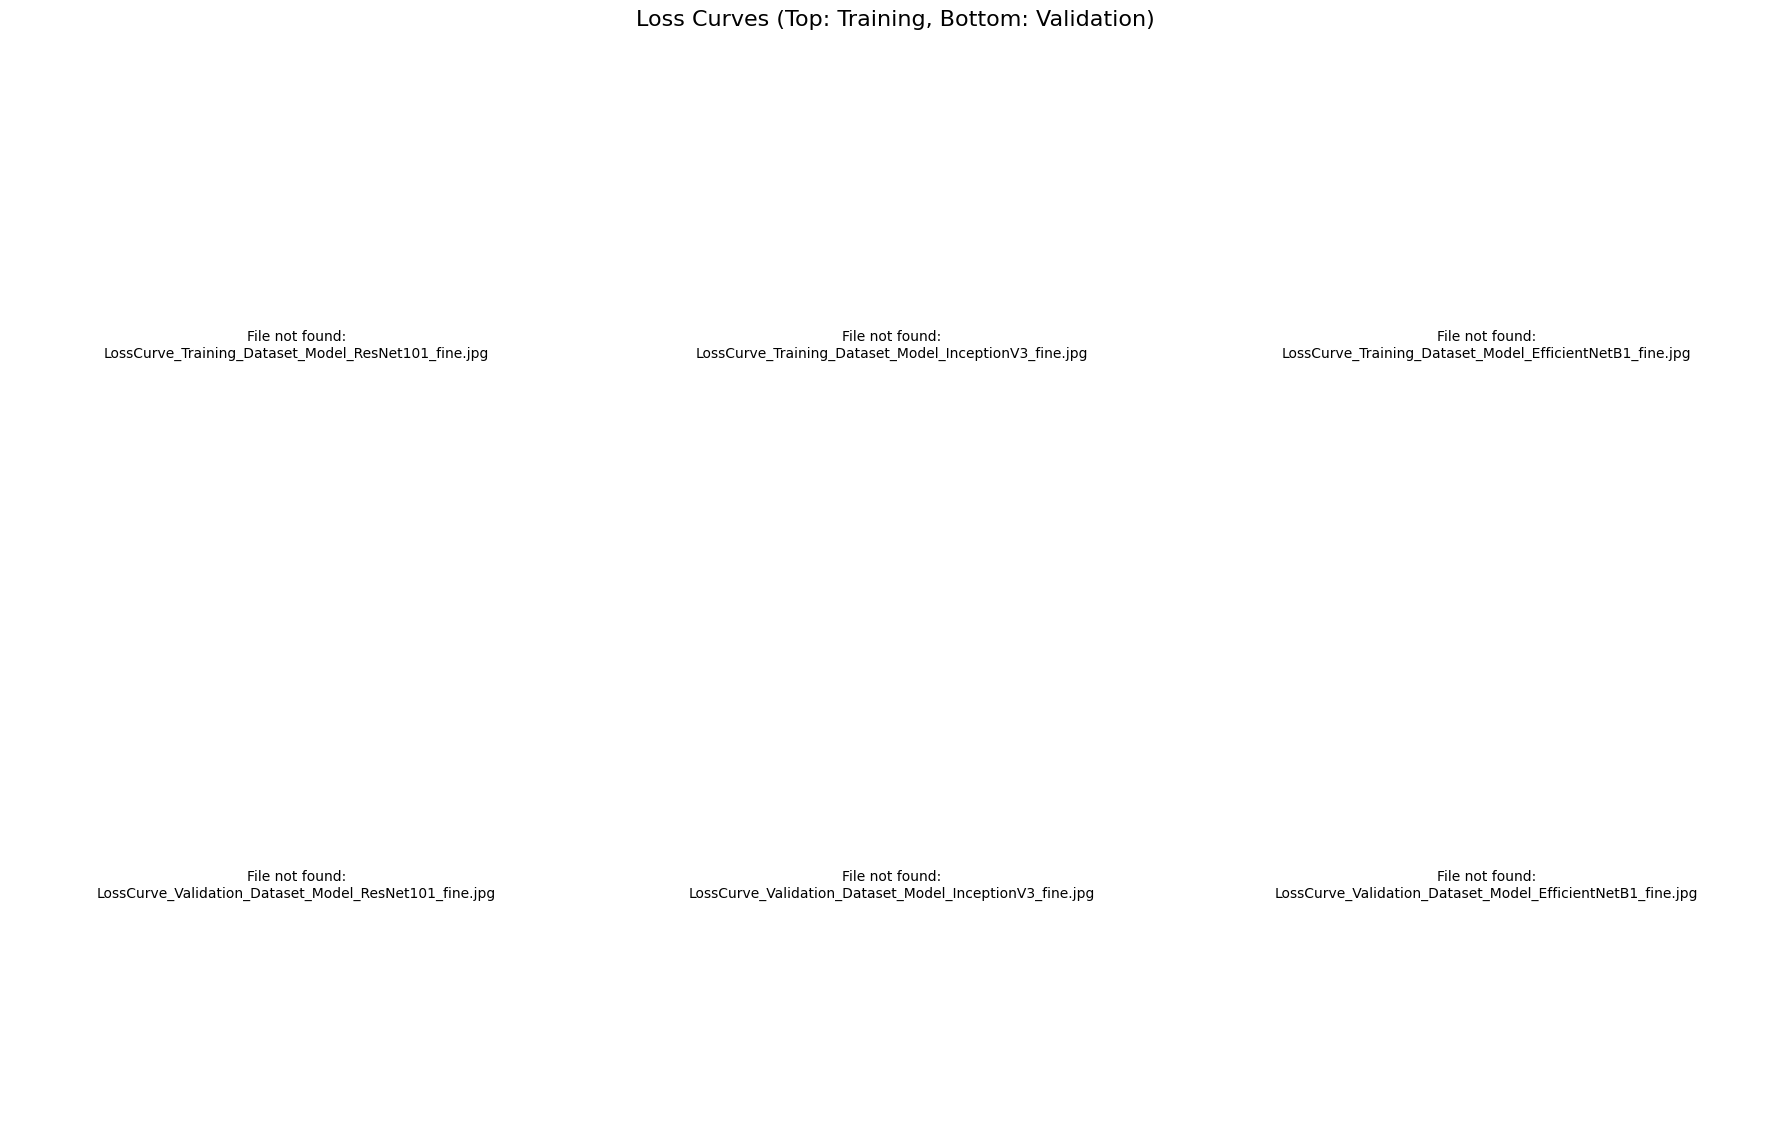

In [22]:
# Deliverable 1.5: Fine tuned models
# Dataframe: second_experiment_df

# Report accuracies
# Display as a clean HTML table (use display() in Jupyter instead of print())
try:
    display(second_experiment_df.style.hide(axis=0).set_properties(
        **{'text-align': 'center', 'border': '1px solid #ddd'}
    ).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}]))
except NameError as e:
    print(f"Error: {e}. Run the model training cells first.")

# Print loss curves
# Display in grid 3x2

# Define subfolder and filenames
# If local:
# plot_folder = "HW_03_Transfer/plots"
# If running in Colab online:
plot_folder = "/content/Plot JPGs Ex2"

# Debug: List files to ensure we have the right names
if os.path.exists(plot_folder):
    print(f"Files in {plot_folder}: {os.listdir(plot_folder)}")
else:
    print(f"Folder {plot_folder} not found!")


# Rows: Training, Validation
# Cols: Models

models = ["ResNet101_fine", "InceptionV3_fine", "EfficientNetB1_fine"]
datasets = ["Training", "Validation"]

# Increased figure height to 12 to allow more space
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Loss Curves (Top: Training, Bottom: Validation)", fontsize=16)

for row_idx, dataset in enumerate(datasets):
    for col_idx, model in enumerate(models):
        # Filename format from plot_loss: LossCurve_{dataset}_Dataset_Model_{model}.jpg
        fname = f"LossCurve_{dataset}_Dataset_Model_{model}.jpg"
        img_path = os.path.join(plot_folder, fname)
        ax = axs[row_idx, col_idx]

        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.set_title(f"{dataset} Loss (Model={model})", fontsize=12)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, f"File not found:\n{fname}", ha='center', va='center')
            ax.axis('off')

# Added h_pad=3.0 to increase vertical spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)
plt.show()

In [23]:
# Deliverable 2: Prediction time table
# Dataframe: prediction_results_df

# Display as a clean HTML table (use display() in Jupyter instead of print())
try:
    display(prediction_results_df.style.hide(axis=0).set_properties(
        **{'text-align': 'center', 'border': '1px solid #ddd'}
    ).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}]))
except NameError as e:
    print(f"Error: {e}. Run the model evaluation cells first.")

Discussion Section

Discuss the roles that transfer learning and frozen layers play within transfer learning tasks.



Discuss the trade-offs between computational resource utilization with the accuracy levels and model sizes for the classification task.

